In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import itertools
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.utils import resample

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 150

FIG_DIR = "../figures/"
TAB_DIR = "../tables/"
for d in [FIG_DIR, TAB_DIR]: os.makedirs(d, exist_ok=True)

log_path = '../tables/experiments.csv'
if os.path.exists(log_path):
    df = pd.read_csv(log_path)
else:
    print("Error: experiments.csv not found. Please run `python run_all.py` from the project root first.")

Experiment Log loaded with success: 62 executions found.


Resume of metrics per K:


silhouette                 davies_bouldin                  \
         mean     std     max           mean     std     min   
k                                                              
3      0.1478  0.0168  0.1730         2.0424  0.1597  1.8503   
4      0.1403  0.0118  0.1576         1.9183  0.2102  1.6217   
5      0.1544  0.0037  0.1591         1.8157  0.1476  1.6754   
6      0.1433  0.0075  0.1521         1.8383  0.1001  1.7596   
7      0.1362  0.0012  0.1378         1.8955  0.1248  1.7772   
8      0.1426  0.0103  0.1533         1.8576  0.1644  1.7029   
11     0.1317     NaN  0.1317         2.0267     NaN  2.0267   
14     0.1371     NaN  0.1371         1.8358     NaN  1.8358   

   calinski_harabasz                         
                mean        std         max  
k                                            
3         16844.7774  1751.8406  18503.3531  
4         16303.4289  1021.3516  17201.6127  
5         15647.0372   181.5594  15819.2835  
6         14801.7284   554.9997  15378.7046  
7         13989.8784   767.2627  14717.7787  
8         13144.1869   942.2104  14036.9519  
11         9510.7291        NaN   9510.7291  
14        10029.0144        NaN  10029.0144

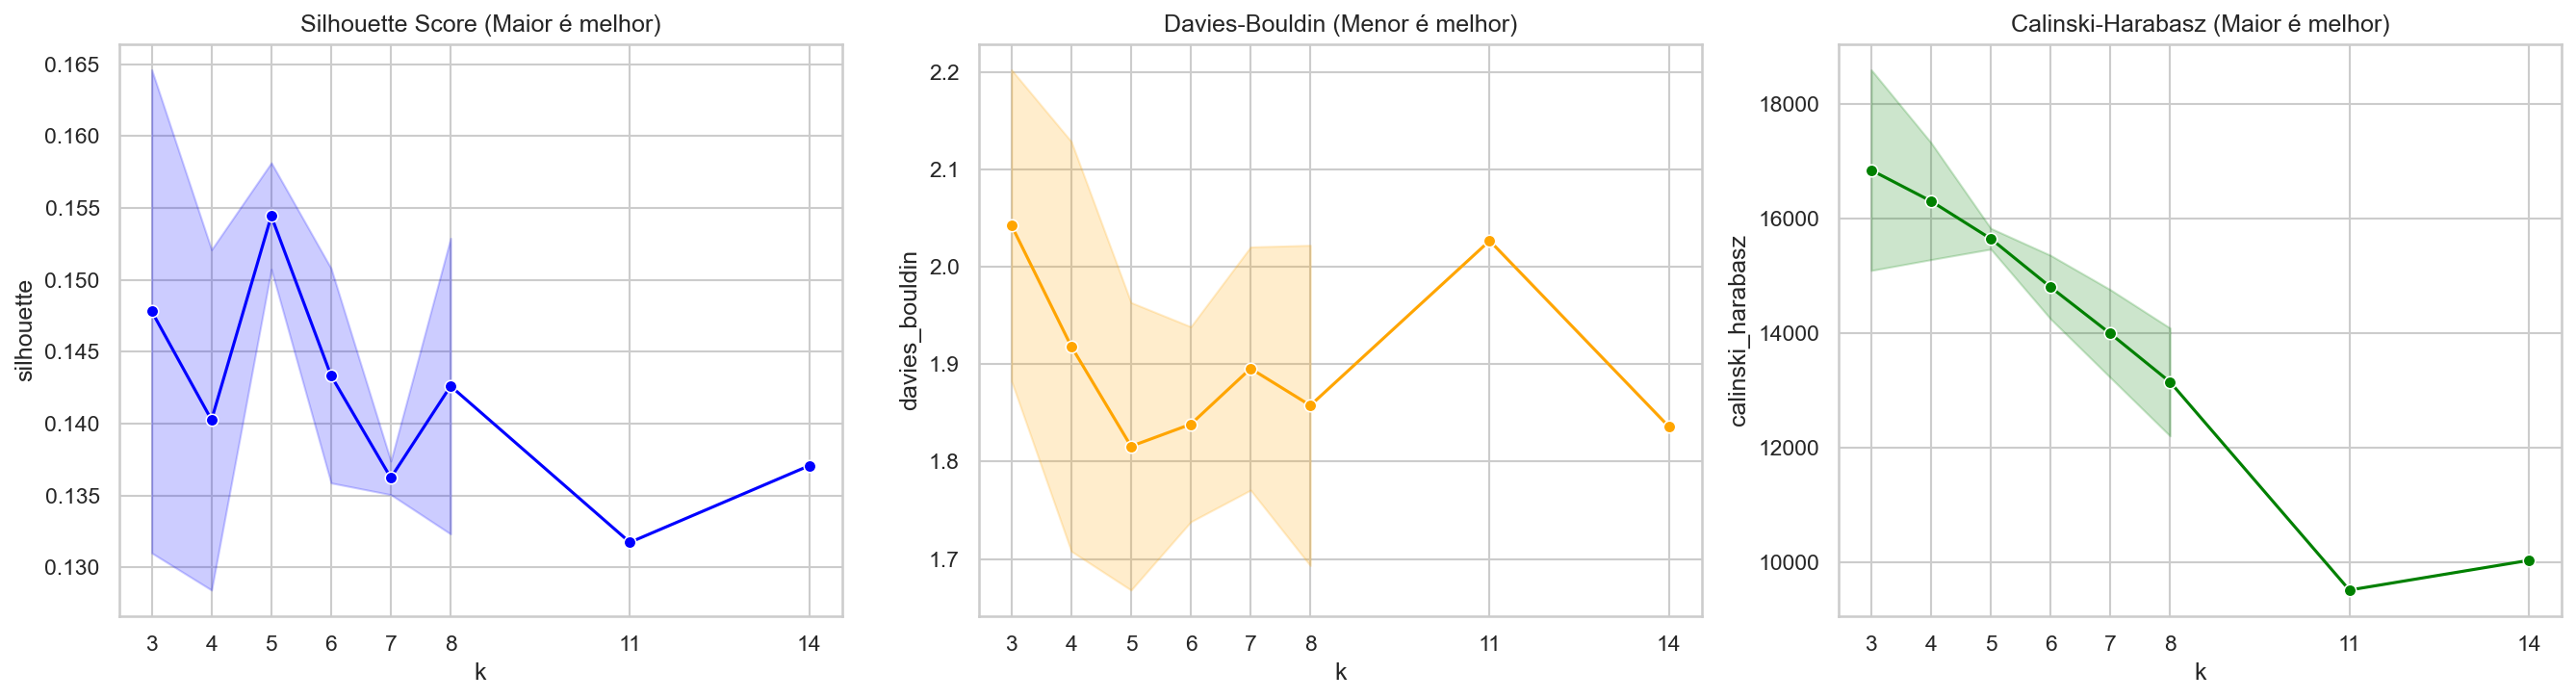

In [8]:
resumo_k = df.groupby('k').agg({
    'silhouette': ['mean', 'std', 'max'],
    'davies_bouldin': ['mean', 'std', 'min'],
    'calinski_harabasz': ['mean', 'std', 'max']
}).round(4)

print("Resume of metrics per K:")
display(resumo_k)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Silhouette
sns.lineplot(data=df, x='k', y='silhouette', marker='o', errorbar='sd', ax=axes[0], color='blue')
axes[0].set_title('Silhouette Score (Maior é melhor)')
axes[0].set_xticks(df['k'].unique())

# Plot Davies-Bouldin
sns.lineplot(data=df, x='k', y='davies_bouldin', marker='o', errorbar='sd', ax=axes[1], color='orange')
axes[1].set_title('Davies-Bouldin (Menor é melhor)')
axes[1].set_xticks(df['k'].unique())

# Plot Calinski-Harabasz
sns.lineplot(data=df, x='k', y='calinski_harabasz', marker='o', errorbar='sd', ax=axes[2], color='green')
axes[2].set_title('Calinski-Harabasz (Maior é melhor)')
axes[2].set_xticks(df['k'].unique())

plt.tight_layout()
plt.show()

In [9]:
X_scaled_standard = pd.read_csv('../tables/X_scaled_matrix_standard.csv').values
X_scaled_robust = pd.read_csv('../tables/X_scaled_matrix_robust.csv').values

In [10]:
def kmeans_bootstrap_stability(X, K, n_boot=20, seed=0):
    if isinstance(X, pd.DataFrame):
        X = X.values
        
    n_samples = X.shape[0]
    boot_indices = []
    boot_labels = []

    for i in range(n_boot):
        indices = resample(np.arange(n_samples), random_state=seed+i)
        X_boot = X[indices]

        model = KMeans(n_clusters=K, random_state=seed+i, n_init=10)
        labels = model.fit_predict(X_boot)

        boot_indices.append(indices)
        boot_labels.append(labels)

    ari_scores = []
    for i, j in itertools.combinations(range(n_boot), 2):
        idx_i, idx_j = boot_indices[i], boot_indices[j]
        
        intersect = np.intersect1d(idx_i, idx_j)
        if len(intersect) == 0:
            continue
            
        def get_intersect_labels(idx_array, labels_array, intersect_pts):
            mapping = {pt: lbl for pt, lbl in zip(idx_array, labels_array)}
            return [mapping[pt] for pt in intersect_pts]

        labels_i = get_intersect_labels(idx_i, boot_labels[i], intersect)
        labels_j = get_intersect_labels(idx_j, boot_labels[j], intersect)

        ari_scores.append(adjusted_rand_score(labels_i, labels_j))

    return {
        "mean_ARI": np.mean(ari_scores),
        "std_ARI": np.std(ari_scores),
        "n_pairs": len(ari_scores)
    }

# K Values to Test
K_values = [3, 4, 5, 6, 7]
stability_rows = []

Running Bootstrap Stability for K-Means for Standard...
Finished K=3: Mean ARI = 0.891
Finished K=4: Mean ARI = 0.581
Finished K=5: Mean ARI = 0.921
Finished K=6: Mean ARI = 0.940
Finished K=7: Mean ARI = 0.817


,K,mean pairwise ARI,std ARI,n compared resample pairs
0,3,0.891,0.171,190
1,4,0.581,0.289,190
2,5,0.921,0.174,190
3,6,0.940,0.134,190
4,7,0.817,0.179,190


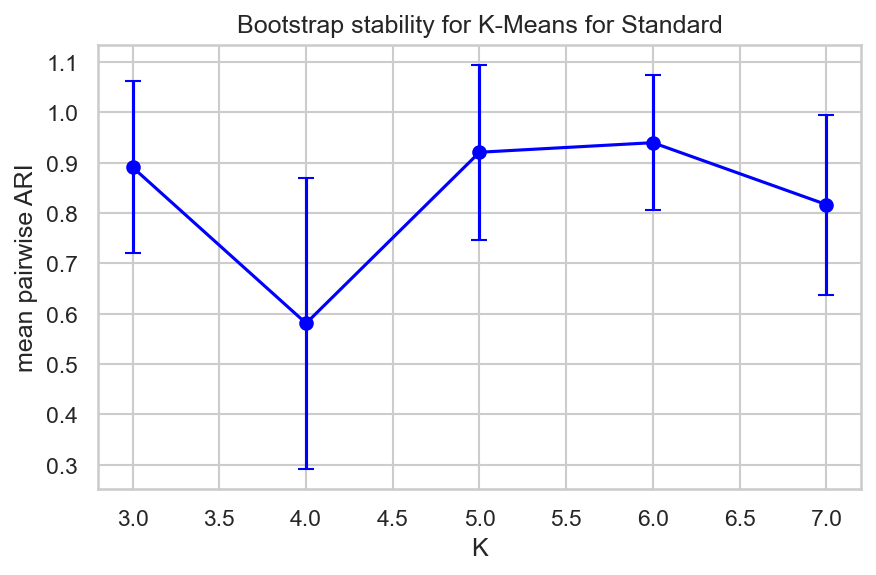

In [11]:
print("Running Bootstrap Stability for K-Means for Standard...")

for K in K_values:
    result = kmeans_bootstrap_stability(X_scaled_standard, K, n_boot=20, seed=42)
    
    stability_rows.append(
        {
            "K": K,
            "mean pairwise ARI": round(result["mean_ARI"], 3),
            "std ARI": round(result["std_ARI"], 3),
            "n compared resample pairs": result["n_pairs"],
        }
    )
    print(f"Finished K={K}: Mean ARI = {result['mean_ARI']:.3f}")

stability_df = pd.DataFrame(stability_rows)
display(stability_df)

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(
    stability_df["K"],
    stability_df["mean pairwise ARI"],
    yerr=stability_df["std ARI"],
    marker="o",
    capsize=4,
    color="blue"
)
ax.set_title("Bootstrap stability for K-Means for Standard")
ax.set_xlabel("K")
ax.set_ylabel("mean pairwise ARI")
plt.tight_layout()
plt.show()

Running Bootstrap Stability for K-Means for Robust...
Finished K=3: Mean ARI = 0.891
Finished K=4: Mean ARI = 0.581
Finished K=5: Mean ARI = 0.921
Finished K=6: Mean ARI = 0.940
Finished K=7: Mean ARI = 0.817


,K,mean pairwise ARI,std ARI,n compared resample pairs
0,3,0.891,0.171,190
1,4,0.581,0.289,190
2,5,0.921,0.174,190
3,6,0.940,0.134,190
4,7,0.817,0.179,190
5,3,0.891,0.171,190
6,4,0.581,0.289,190
7,5,0.921,0.174,190
8,6,0.940,0.134,190
9,7,0.817,0.179,190


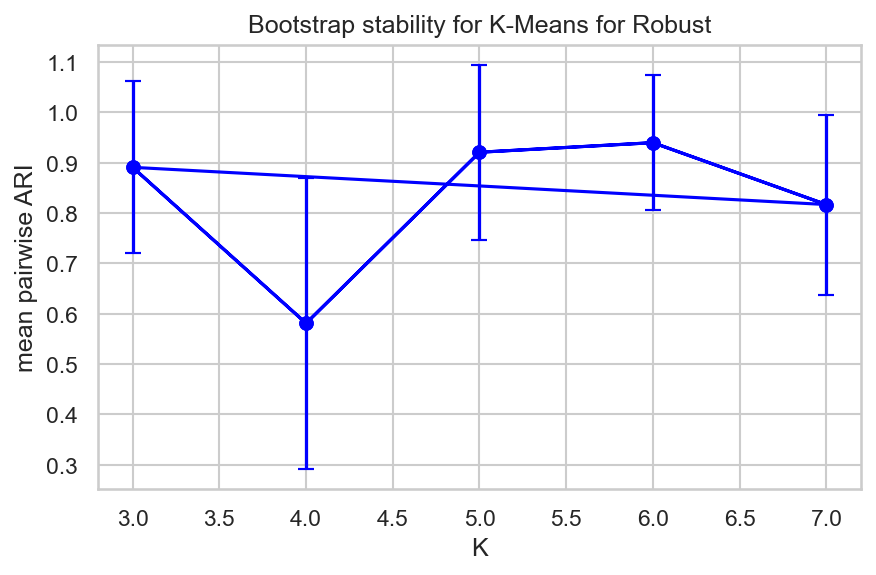

In [12]:
print("Running Bootstrap Stability for K-Means for Robust...")

for K in K_values:
    result = kmeans_bootstrap_stability(X_scaled_robust, K, n_boot=20, seed=42)
    
    stability_rows.append(
        {
            "K": K,
            "mean pairwise ARI": round(result["mean_ARI"], 3),
            "std ARI": round(result["std_ARI"], 3),
            "n compared resample pairs": result["n_pairs"],
        }
    )
    print(f"Finished K={K}: Mean ARI = {result['mean_ARI']:.3f}")

stability_df = pd.DataFrame(stability_rows)
display(stability_df)

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(
    stability_df["K"],
    stability_df["mean pairwise ARI"],
    yerr=stability_df["std ARI"],
    marker="o",
    capsize=4,
    color="blue"
)
ax.set_title("Bootstrap stability for K-Means for Robust")
ax.set_xlabel("K")
ax.set_ylabel("mean pairwise ARI")
plt.tight_layout()
plt.show()

In [ ]:
df_raw = pd.read_csv('../data/raw/hotel_bookings_course_release_v1.csv')
profiling_data = pd.read_csv('../tables/profiling_base_data.csv')

print("Fitting optimal K=5 model...")
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled_standard)

df_interp = pd.DataFrame({
    'lead_time': df_raw['lead_time'],
    'total_nights': df_raw['stays_in_weekend_nights'] + df_raw['stays_in_week_nights'],
    'party_size': df_raw['adults'] + df_raw['children'].fillna(0) + df_raw['babies'],
    'previous_cancellations': df_raw['previous_cancellations']
})

df_interp['is_TA_TO'] = (df_raw['distribution_channel'] == 'TA/TO').astype(int)
df_interp['is_Direct'] = (df_raw['distribution_channel'] == 'Direct').astype(int)
df_interp['is_Transient'] = (df_raw['customer_type'] == 'Transient').astype(int)
df_interp['is_Non_Refund'] = (df_raw['deposit_type'] == 'Non Refund').astype(int)

df_interp['adr'] = profiling_data['adr']
df_interp['is_canceled'] = profiling_data['is_canceled']

df_interp['Cluster'] = labels

grand_mean = df_interp.drop('Cluster', axis=1).mean()
cluster_means = df_interp.groupby('Cluster').mean()

relative_diff = 100 * (cluster_means - grand_mean) / grand_mean
relative_diff_t = relative_diff.T

print("Cluster Interpretation: Relative Differences")

def color_magnitudes(val):
    """Colors large positive deviations red and large negative deviations blue."""
    if val > 50:
        color = "#bb0101"
    elif val > 20:
        color = "#D76262"
    elif val < -50:
        color = "#002E72"
    elif val < -20:
        color = "#5b7da9"
    else:
        color = 'white'
    return f'background-color: {color}'

styled_diff = relative_diff_t.style.map(color_magnitudes).format("{:.1f}%")
display(styled_diff)

relative_diff_t.round(1).to_csv('../tables/cluster_relative_differences.csv')

Fitting optimal K=5 model...
Calculating Grand Means and Cluster Means...
Cluster Interpretation: Relative Differences


Cluster,0,1,2,3,4
lead_time,-85.3%,-92.8%,28.4%,104.6%,24.2%
total_nights,-49.8%,-41.7%,126.6%,-20.1%,-14.5%
party_size,-38.0%,-12.5%,13.7%,-5.9%,3.1%
previous_cancellations,567.3%,-99.9%,-97.2%,1687.9%,-100.0%
is_TA_TO,-81.7%,-28.3%,1.5%,12.4%,12.9%
is_Direct,74.2%,128.2%,19.1%,-79.2%,-54.2%
is_Transient,19.7%,8.2%,3.5%,-31.1%,-2.3%
is_Non_Refund,-96.4%,-92.4%,-86.3%,404.5%,29.5%
adr,-39.4%,-7.7%,10.8%,-23.6%,3.6%
is_canceled,-85.0%,-62.2%,-8.8%,167.0%,16.2%
